In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("transform_johor_prop.csv")
df

,location,property_type,size_sqft,total_bedroom,total_bathroom,land_status,prices
0,johor bahru,high_rise,900,3.0,3.0,Freehold,190000
1,johor bahru,landed,1400,4.0,4.0,Freehold,849000
2,johor bahru,landed,2240,4.0,4.0,Freehold,999000
3,johor bahru,high_rise,667,2.0,2.0,Freehold,330000
4,johor bahru,high_rise,495,1.0,1.0,Freehold,300000
...,...,...,...,...,...,...,...
256,johor bahru,landed,2332,4.0,4.0,Freehold,1003800
257,kluang,landed,1540,4.0,4.0,Freehold,364650
258,muar,landed,4000,4.0,2.0,Freehold,423200
259,kluang,landed,3420,4.0,4.0,Freehold,718000


In [26]:
# OHE for categorical status


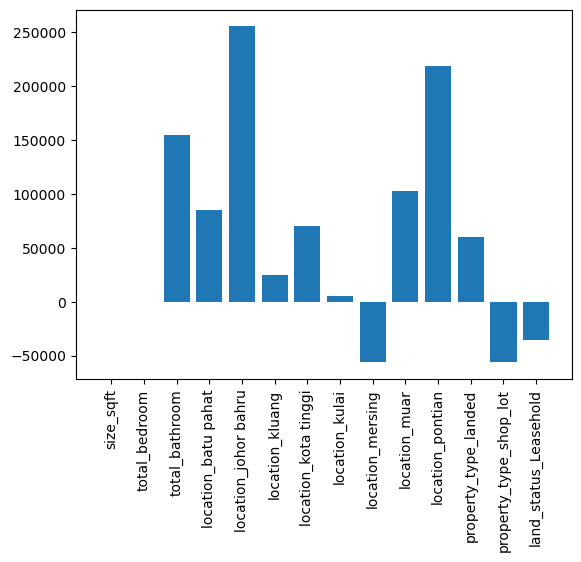

In [27]:
# finding most importance features
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Lasso 

# OHE categorical features
ohe = OneHotEncoder(sparse_output=False, drop="first")
cols = ["location", "property_type", "land_status"]
encoded_cols = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(cols))

df = pd.concat([df, encoded_df], axis = 1)
df.drop(columns=cols, inplace=True)  

# separating features and target variable
X = df.drop("prices", axis = 1).values
y = df["prices"].values
names = df.drop("prices", axis = 1).columns.astype(str)

lasso = Lasso(alpha=0.1)
lasso_coef = lasso.fit(X, y).coef_

# visualizing the coefficients
plt.bar(names, lasso_coef)
plt.xticks(rotation=90)
plt.show()